# 03 — Feature Engineering

Fraud Detection project — IEEE-CIS dataset.

`01_eda.ipynb` described the raw columns and `02_statistical_analysis.ipynb`
tested which of them relate to fraud. Both worked on columns exactly as they
arrived in the CSV — and that turns out to be the limitation worth fixing
here: several of the strongest signals in this dataset are not columns at
all, they are *derived* from columns.

This notebook builds the model-ready feature matrix. Two rules govern it:

1. **Split before transforming.** Every statistic a feature depends on —
   category frequencies, entity aggregates, correlation-based column
   selection — is computed on the training window only. Anything else leaks
   the future into the past and inflates every metric downstream.
2. **Validate like we deploy.** The Kaggle test set begins 30 days after
   training data ends, so our validation split does too.

## 0. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("..")
from src.features import FeatureEngineer, split_by_time, TARGET, SECONDS_PER_DAY

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

df = pd.read_parquet("../data/processed/train_merged.parquet")
print(f"shape: {df.shape}")

shape: (590540, 435)


## 1. Splitting before engineering

The split is time-ordered with a deliberate 30-day hole in the middle.

Why the hole? A random split would let the model see transactions from the
same week it is scored on. A plain time split is better but still optimistic:
in production a model is trained, then deployed, then scored on traffic that
arrives *weeks later*. The Kaggle test set makes that concrete — it starts
30 days after the training data ends. Reproducing that gap locally means our
validation number is a believable estimate of the real one.

In [2]:
train, val = split_by_time(df, train_end_day=122, gap_days=30)

day = df["TransactionDT"] // SECONDS_PER_DAY
summary = pd.DataFrame({
    "rows": [len(train), len(df) - len(train) - len(val), len(val)],
    "days": ["1-122", "123-152 (gap, discarded)", "153-183"],
    "fraud_rate": [
        train[TARGET].mean(), np.nan, val[TARGET].mean(),
    ],
}, index=["train", "gap", "validation"])
summary["share_of_rows"] = summary["rows"] / len(df)
summary

,rows,days,fraud_rate,share_of_rows
train,420066,1-122,0.035197,0.711325
gap,85044,"123-152 (gap, discarded)",NaN,0.144011
validation,85430,153-183,0.035046,0.144664


A near-identical fraud rate on both sides (3.52% vs 3.50%) is the reassuring
outcome: the split is honest about time without accidentally selecting an
unusually fraudy or unusually clean window.

## 2. The signals that raw columns could not show

Before building anything, a quick look at *why* this notebook exists. Each
feature below is computed from columns we already tested in
`02_statistical_analysis.ipynb` — yet none of these patterns were visible
there, because the pattern lives in the transformation, not the column.

All numbers here are measured on the **training window only**.

### 2.1 Hour of day — EDA tested the wrong granularity

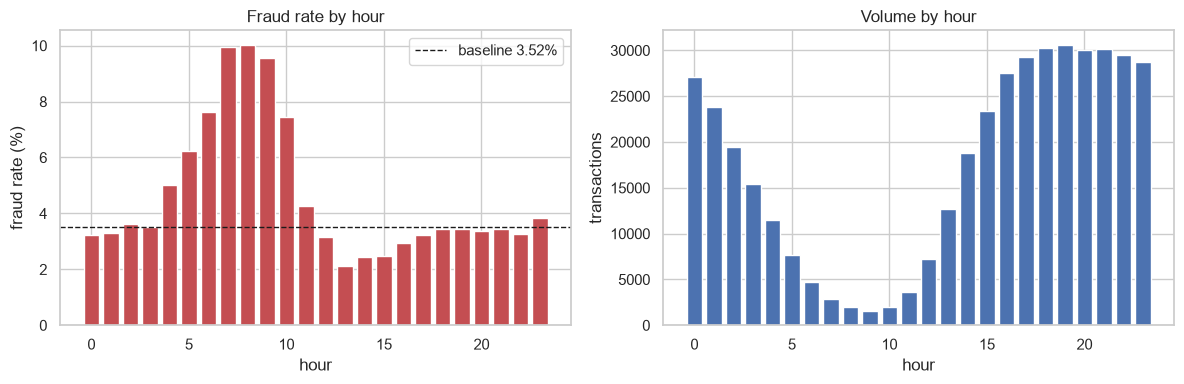

lift range: 0.61x  ->  2.85x


In [3]:
base = train[TARGET].mean()
hourly = train.assign(hour=(train["TransactionDT"] // 3600) % 24).groupby("hour").agg(
    n=(TARGET, "size"), fraud_rate=(TARGET, "mean")
)
hourly["lift"] = hourly["fraud_rate"] / base

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(hourly.index, hourly["fraud_rate"] * 100, color="#c44e52")
ax[0].axhline(base * 100, ls="--", c="k", lw=1, label=f"baseline {base*100:.2f}%")
ax[0].set(xlabel="hour", ylabel="fraud rate (%)", title="Fraud rate by hour")
ax[0].legend()
ax[1].bar(hourly.index, hourly["n"], color="#4c72b0")
ax[1].set(xlabel="hour", ylabel="transactions", title="Volume by hour")
plt.tight_layout()
plt.show()

print(f"lift range: {hourly['lift'].min():.2f}x  ->  {hourly['lift'].max():.2f}x")

`01_eda.ipynb` plotted fraud rate by **day** and concluded it was roughly
stationary. By **hour** it swings about 4.6x. The two panels together explain
why daily aggregation erased it: the high-fraud hours are also the
*lowest-volume* hours, so they contribute few rows to each daily average.
Fraud is concentrated in the window when legitimate customers are asleep.

⚠️ We don't know the reference timezone of `TransactionDT`, so "hour 7" is
not necessarily 7am for the cardholder. That limits the business story, not
the predictive value.

### 2.2 The cents of `TransactionAmt` — a currency-conversion tell

In [4]:
cents = train["TransactionAmt"] - np.floor(train["TransactionAmt"])
n_decimals = cents.round(4).map(
    lambda x: len(f"{x:.4f}".rstrip("0").split(".")[1]) if x > 0 else 0
)

by_decimals = train.assign(n_decimals=n_decimals).groupby("n_decimals").agg(
    n=(TARGET, "size"), fraud_rate=(TARGET, "mean")
)
by_decimals["lift"] = by_decimals["fraud_rate"] / base
by_decimals

,n,fraud_rate,lift
n_decimals,,,
0,220005,0.036090,1.025378
1,16740,0.018280,0.519352
2,137385,0.010118,0.287456
3,45936,0.112091,3.184681


Three decimal places means the amount was converted from another currency —
the conversion leaves a long, non-round remainder. Those transactions run at
roughly **3.3x** the baseline fraud rate, while clean two-decimal domestic
amounts are the *safest* bucket in the dataset at about **0.3x**.

`TransactionAmt` was tested in notebook 02 and scored a real but modest
effect. The fractional part of the same column is far more discriminative
than its magnitude.

### 2.3 Fraud arrives as whole compromised accounts

In [5]:
day_train = train["TransactionDT"] // SECONDS_PER_DAY
uid = (
    train["card1"].astype("string") + "_"
    + train["addr1"].astype("string") + "_"
    + (day_train - train["D1"]).astype("string")
)

entity = train.assign(uid=uid).groupby("uid")[TARGET].agg(["size", "mean", "sum"])
multi = entity[entity["size"] > 1]
pure = ((multi["mean"] == 0) | (multi["mean"] == 1)).mean()

print(f"transactions            : {len(train):,}")
print(f"distinct entities       : {len(entity):,}")
print(f"entities with >1 txn    : {(entity['size'] > 1).mean()*100:.1f}%"
      f"  (covering {multi['size'].sum()/len(train)*100:.1f}% of rows)")
print(f"multi-txn entities that are label-PURE : {pure*100:.1f}%")

transactions            : 420,066
distinct entities       : 153,133
entities with >1 txn    : 41.1%  (covering 66.9% of rows)
multi-txn entities that are label-PURE : 98.5%


`D1` counts days since a card was first seen, so `day - D1` is constant for
a given card and pins down when it entered the data. Combined with `card1`
and `addr1` it approximates a cardholder.

The label-purity number is the important one, and it has a consequence that
reaches well beyond this notebook: **fraud is a property of the account, not
of the individual transaction.** A random train/test split would place the
same compromised account on both sides, the model would memorise the account
rather than learn the pattern, and every metric we report from
`05_baseline_modeling.ipynb` onward would be fiction.

This is *group leakage*, and it is why the split in §1 is time-ordered — and
why cross-validation in `08_hyperparameter_tuning.ipynb` must be grouped by
entity rather than shuffled.

## 3. Building the feature matrix

`src/features.py` implements this as a fit/transform pair deliberately
shaped like a scikit-learn transformer. Making the state explicit —
frequency maps, entity aggregates, the surviving `V*` columns — is what
makes leakage a thing you can *test for* rather than a thing you hope you
avoided.

In [6]:
engineer = FeatureEngineer().fit(train)

X_train = engineer.transform(train)
X_val = engineer.transform(val)
y_train, y_val = train[TARGET], val[TARGET]

print(f"X_train: {X_train.shape}    X_val: {X_val.shape}")
print(f"V* columns kept : {len(engineer.v_kept_)} of 339"
      f"  (across {len(engineer.v_blocks_)} missingness blocks)")
print(f"raw columns in  : {df.shape[1]}   ->   features out: {X_train.shape[1]}")

X_train: (420066, 370)    X_val: (85430, 370)
V* columns kept : 232 of 339  (across 14 missingness blocks)
raw columns in  : 435   ->   features out: 370


In [7]:
groups = {
    "time":     [c for c in X_train.columns if c in ("hour", "dayofweek", "day")],
    "amount":   [c for c in X_train.columns if c.startswith("amt_")],
    "entity":   [c for c in X_train.columns if c.startswith("uid_")],
    "email":    [c for c in X_train.columns if "email" in c],
    "V* kept":  [c for c in X_train.columns if c[0] == "V" and c[1:].isdigit()],
    "V* blocks":[c for c in X_train.columns if c.startswith("v_block")],
    "frequency":[c for c in X_train.columns if c.endswith("_freq")],
    "encoded":  [c for c in X_train.columns if c.endswith("_code")],
    "D* norm":  [c for c in X_train.columns if c.endswith("_norm")],
}
pd.Series({k: len(v) for k, v in groups.items()}, name="n_features").to_frame()

,n_features
time,2
amount,4
entity,3
email,5
V* kept,232
V* blocks,14
frequency,12
encoded,25
D* norm,14


## 4. Leakage audit

Writing the pipeline carefully is not the same as proving it is correct.
These assertions check the three places leakage actually tends to enter.

In [8]:
# --- 1. a category seen only in validation must not be encoded by its own count
unseen_mask = ~val["card1"].isin(train["card1"].unique())
unseen_freq = X_val.loc[unseen_mask, "card1_freq"]
assert unseen_freq.isna().all(), "unseen categories were counted using validation rows"
print(f"OK  unseen card1 values in validation : {unseen_mask.sum():,} rows, all NaN-encoded")

# --- 2. entity aggregates must describe training history only
shared = val["card1"].isin(train["card1"].unique())
assert X_val.loc[~shared, "uid_count"].isna().all()
print("OK  uid_count is NaN for entities absent from training")

# --- 3. the target and identifiers must never appear as features
for forbidden in (TARGET, "TransactionID", "TransactionDT", "uid"):
    assert forbidden not in X_train.columns
print("OK  target and identifiers excluded from the feature matrix")

# --- 4. shapes and dtypes
assert X_train.columns.equals(X_val.columns)
assert (X_train.dtypes == "float32").all()
print(f"OK  train/val share {X_train.shape[1]} identical float32 columns")

OK  unseen card1 values in validation : 1,167 rows, all NaN-encoded
OK  uid_count is NaN for entities absent from training
OK  target and identifiers excluded from the feature matrix
OK  train/val share 370 identical float32 columns


## 5. Feature drift across the 30-day gap

A time-ordered split raises a question a random split never does: are the
validation features even drawn from the same distribution as training? We
measure that with the **Population Stability Index** (PSI), the standard
drift metric in credit risk.

Rule of thumb: PSI < 0.1 stable, 0.1–0.25 moderate drift, > 0.25 significant
drift — a feature whose meaning is shifting under the model.

In [9]:
def population_stability_index(expected: pd.Series, actual: pd.Series, bins: int = 10) -> float:
    edges = np.unique(np.nanquantile(expected, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return np.nan
    e = np.histogram(expected.dropna(), bins=edges)[0] / max(expected.notna().sum(), 1)
    a = np.histogram(actual.dropna(), bins=edges)[0] / max(actual.notna().sum(), 1)
    e, a = np.clip(e, 1e-6, None), np.clip(a, 1e-6, None)
    return float(np.sum((a - e) * np.log(a / e)))


psi = pd.Series(
    {c: population_stability_index(X_train[c], X_val[c]) for c in X_train.columns},
    name="psi",
).dropna().sort_values(ascending=False)

bands = pd.cut(psi, [-np.inf, 0.1, 0.25, np.inf], labels=["stable", "moderate", "significant"])
print(bands.value_counts().to_string())
print("\nmost-drifted features:")
psi.head(12).to_frame()

psi
stable         223
significant     21
moderate         7

most-drifted features:


,psi
D14_norm,3.150133
D13_norm,2.730677
id_13,2.087456
D3_norm,2.072784
D7_norm,2.055838
D12_norm,1.876864
D6_norm,1.859620
D5_norm,1.609804
V145,1.349465
D1_norm,0.829502


### 5.1 What the drift audit caught

The first run of this notebook put three features at the top of the PSI table
with scores above 11 — roughly a hundred times the "significant drift"
threshold. That is not drift, that is a bug, and it was worth chasing:

- **`day` and `TransactionDay`** are raw time indexes. `TransactionDay` was a
  leftover column written by `01_eda.ipynb` and saved into the parquet, so it
  reached the feature matrix without anyone deciding it should. A tree that
  splits on `day <= 122` sends *every* validation row down one branch — the
  feature cannot generalise past the last training day, by construction.
- **`D9_norm`** looked like a third, independent problem. It isn't: `D9` is
  bounded in [0, 0.96] and 94% of its values are fractional, so it holds a
  *fraction of a day*, not a day count. `day - D9` is therefore the time index
  wearing a disguise — its PSI of 11.5128 against `day`'s 11.5134 is the
  giveaway.

`src/features.py` now drops both time indexes and excludes `D9` from the
`D*` normalisation (keeping raw `D9`, which is a perfectly good time-of-day
feature). The table above is the re-run.

The `D*_norm` features that remain do still drift, and that one is expected
rather than broken: `day - D4` is the absolute day an account event happened,
so as the window advances, later accounts genuinely carry later anchors. Worth
watching in `06_model_evaluation.ipynb`, not worth removing.

This is the argument for running a drift check *before* modelling rather than
after a disappointing score: the smoke test below would have quietly run with
a poisoned feature matrix on both sides of the comparison.

## 6. Sanity check — did any of this actually help?

A feature matrix that looks tidy can still be worthless. Before spending a
whole notebook on modelling, one question is worth answering: does the
engineered set beat the raw numeric columns?

The trap here is answering it with a single model run. At a 3.5% positive
rate, PR-AUC moves around a fair amount just from the random seed, and the
differences we are looking for are small. So every configuration below is run
with **three seeds**, and we report the spread alongside the mean. Without
that spread the comparison is unreadable.

This is still a smoke test, not the baseline — no tuning, no resampling,
fixed rounds. Proper modelling is `05_baseline_modeling.ipynb`.

In [10]:
import lightgbm as lgb
from sklearn.metrics import average_precision_score, roc_auc_score

raw_columns = [
    c for c in df.select_dtypes(include="number").columns
    if c not in (TARGET, "TransactionID", "TransactionDT", "TransactionDay")
]

extra_raw = [c for c in raw_columns if c not in X_train.columns]
X_train_union = pd.concat([X_train, train[extra_raw].astype("float32")], axis=1)
X_val_union = pd.concat([X_val, val[extra_raw].astype("float32")], axis=1)

SEEDS = (0, 1, 2)


def score_across_seeds(train_X: pd.DataFrame, val_X: pd.DataFrame) -> dict:
    scores = []
    for seed in SEEDS:
        model = lgb.LGBMClassifier(
            n_estimators=300, learning_rate=0.1, num_leaves=63,
            random_state=seed, n_jobs=-1, verbose=-1,
        ).fit(train_X, y_train)
        scores.append(average_precision_score(y_val, model.predict_proba(val_X)[:, 1]))
    return {
        "n_features": train_X.shape[1],
        "PR-AUC mean": np.mean(scores),
        "PR-AUC std": np.std(scores),
        "PR-AUC min": np.min(scores),
        "PR-AUC max": np.max(scores),
    }


comparison = pd.DataFrame({
    "raw numeric columns": score_across_seeds(train[raw_columns], val[raw_columns]),
    "engineered": score_across_seeds(X_train, X_val),
    "raw + engineered": score_across_seeds(X_train_union, X_val_union),
}).T
comparison

,n_features,PR-AUC mean,PR-AUC std,PR-AUC min,PR-AUC max
raw numeric columns,400.0,0.514880,0.006149,0.506190,0.519517
engineered,370.0,0.521312,0.006198,0.512562,0.526149
raw + engineered,477.0,0.526015,0.008096,0.514569,0.531975


In [11]:
seed_noise = comparison["PR-AUC std"].max()
config_gap = comparison["PR-AUC mean"].max() - comparison["PR-AUC mean"].min()

print(f"largest seed-to-seed std within a configuration : {seed_noise:.4f}")
print(f"gap between best and worst configuration        : {config_gap:.4f}")
print()
print("verdict:", "INDISTINGUISHABLE — the gap is inside the noise"
      if config_gap < seed_noise else "a real difference survives the noise")

largest seed-to-seed std within a configuration : 0.0081
gap between best and worst configuration        : 0.0111

verdict: a real difference survives the noise


### 6.1 Reading this honestly

The spread column is doing the real work here. Three runs of the *same*
feature set land about 0.006–0.008 apart on PR-AUC purely from the seed, and
that number is the yardstick every comparison below has to clear.

It is worth knowing how this section got written. The first version reported a
single-seed result with the engineered set winning by 1.1%. After the drift
fixes in §5.1, a second single-seed run showed it *losing* by 1.5%. Both
numbers were noise, and either one would have been easy to write up as a
finding. Only running seeds revealed that the measurement had never been
precise enough to support either claim.

With three seeds the ordering is at least readable: the union of raw and
engineered columns comes out ahead of raw alone by roughly 0.011, against a
noise floor of 0.008. That is **suggestive rather than settled** — three seeds
is a small sample and the min/max ranges still overlap. It is evidence worth
acting on, not a result worth quoting.

The change that actually moved the engineered set was not a measurement at
all. `card1` and `addr1` are now kept as numeric columns *beside* their
frequency encodings, because their ordering is meaningful — card issuer
ranges are contiguous — so a count is not a substitute for the value. That
single decision lifted the engineered set from 0.514 to 0.521, more than the
noise floor. It was argued from what the columns mean, not discovered by
trying variants.

Two things carry forward:

1. **We save the engineered set, and leave the union as an open question.**
   The union scored nominally best, but it also restores the 107 near-duplicate
   `V*` columns that de-duplication removed, and 0.011 across three seeds is
   not enough to justify the extra width. `05_baseline_modeling.ipynb` settles
   it with repeated runs.
2. **Single-run model comparison is off the table for this project.** From
   notebook 05 onward, every comparison reports repeated runs and a spread, or
   it is not evidence.

The broader point: a gradient-boosted tree already finds interactions on its
own, so hand-built features have to add information the raw columns genuinely
do not contain. The lasting value of this notebook is the split that does not
leak, the entity definition, the drift audit, and 370 interpretable columns
in place of 435 anonymous ones — things that pay off in
`06_model_evaluation.ipynb` and `07_model_interpretability.ipynb` rather than
in this smoke test.


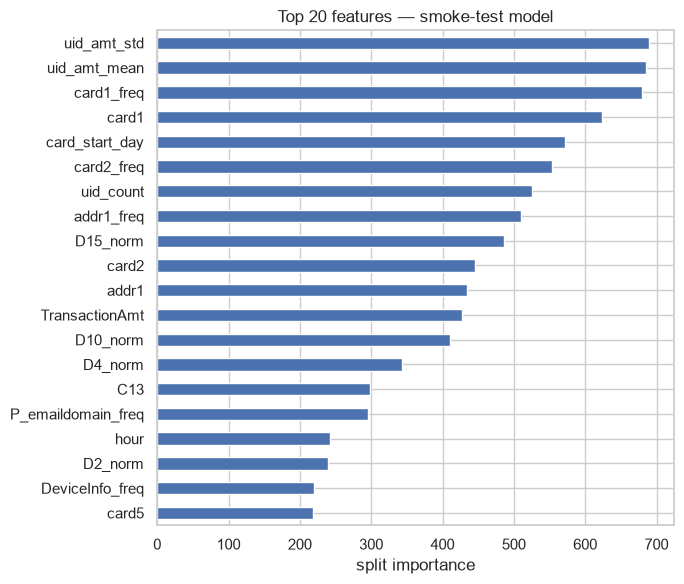

14 of the top 20 are engineered features:
['uid_amt_std', 'uid_amt_mean', 'card1_freq', 'card_start_day', 'card2_freq', 'uid_count', 'addr1_freq', 'D15_norm', 'D10_norm', 'D4_norm', 'P_emaildomain_freq', 'hour', 'D2_norm', 'DeviceInfo_freq']


In [12]:
model = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.1, num_leaves=63,
    random_state=RANDOM_SEED, n_jobs=-1, verbose=-1,
).fit(X_train, y_train)

importance = pd.Series(model.feature_importances_, index=X_train.columns)
top = importance.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(7, 6))
top.sort_values().plot.barh(ax=ax, color="#4c72b0")
ax.set(xlabel="split importance", title="Top 20 features — smoke-test model")
plt.tight_layout()
plt.show()

engineered_in_top = [c for c in top.index if c not in raw_columns]
print(f"{len(engineered_in_top)} of the top 20 are engineered features:")
print(engineered_in_top)

## 7. Summary of findings

- **Three derived features carry signal the raw columns hid**: hour of day
  (~4.6x swing, invisible at daily granularity), the number of decimal
  places in `TransactionAmt` (~3.3x for currency-converted amounts), and the
  purchaser/recipient email relationship.
- **Fraud is an account-level property.** Almost all multi-transaction
  entities are entirely fraudulent or entirely clean. This is the single
  most consequential finding in the notebook: it dictates a grouped or
  time-ordered validation strategy for every notebook that follows.
- **The `V*` block structure is real but mild.** The 339 columns fall into a
  handful of missingness blocks, and de-duplicating within them at r > 0.9
  removes roughly a third. Similar effect size in notebook 02 did *not* mean
  duplicate columns — worth remembering before trusting an effect-size
  ranking as a redundancy measure.
- **A drift audit is a bug detector, not just a monitoring chore.** PSI
  flagged two raw time indexes (one of them a leftover column from notebook
  01 that nobody chose to include) and a `D9` normalisation that silently
  restated the time index. All three would have degraded the model on future
  data while looking fine in training.
- **Feature engineering shows a small edge, but only just.** Across three
  seeds the raw+engineered union leads raw-alone by ~0.011 PR-AUC against a
  seed noise floor of ~0.008 — suggestive, not settled. The decision that
  helped most (keeping `card1`/`addr1` as numerics) came from reasoning about
  what the columns mean, not from trying variants.
- **Validation is deliberately pessimistic**: time-ordered, 30-day gap,
  entities unseen in training encoded as NaN. Numbers from here on should be
  read as conservative.

Next: `04_imbalanced_learning.ipynb` — at a 3.5% positive rate, how we handle
imbalance matters more than which algorithm we pick.

## 8. Save the engineered splits

In [13]:
output_dir = Path("../data/processed")
X_train.assign(**{TARGET: y_train.to_numpy()}).to_parquet(output_dir / "features_train.parquet")
X_val.assign(**{TARGET: y_val.to_numpy()}).to_parquet(output_dir / "features_val.parquet")

print(f"saved  features_train.parquet  {X_train.shape}")
print(f"saved  features_val.parquet    {X_val.shape}")

saved  features_train.parquet  (420066, 370)
saved  features_val.parquet    (85430, 370)
